In [3]:
!pip install gensim

  Using cached gensim-4.3.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.1 kB)
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached scipy-1.13.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
Using cached gensim-4.3.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (26.7 MB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
Using cached scipy-1.13.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (38.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.1
    Uninstalling scipy-1.16.1:
      Successfully uninstalled scipy-1.16.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are install

In [1]:
from sklearn.manifold import TSNE
from bokeh.io import output_notebook
from bokeh.plotting import figure, show
from bokeh.models import HoverTool, CustomJS, ColumnDataSource, Slider
from bokeh.layouts import column
from bokeh.palettes import all_palettes
output_notebook()

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
pip install pdfminer.six

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 57.9 MB/s eta 0:00:00


In [4]:
import pandas as pd
from pdfminer.high_level import extract_pages
from pdfminer.layout import LTTextContainer

In [5]:
dataset=[]
record=[]
name=""

In [6]:
for i in range (1,21):
    print(i)
    text1=""
    name="pdf"+ str(i)+".pdf"
    for page_layout in extract_pages(name):
        for element in page_layout:
            if isinstance(element, LTTextContainer):
                #print(element.get_text())
                text1=text1+element.get_text()+"\n"
    record.append(text1)


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20


In [7]:
import pandas as pd

# Define a dictionary containing data
data = {'Name': ["paper 1", "paper 2", " paper 3 ", "paper 4","paper 5","paper 6","paper 7","paper 8","paper 9","paper 10","paper 11","paper 12","paper 13","paper 14","paper 15","paper 16","paper 17","paper 18","paper 19","paper 20"] }
# Convert the dictionary into DataFrame
df = pd.DataFrame(data)

In [8]:
df["content"] = record

In [9]:
df.info()
df.to_csv('healthrecordpdfcontent.csv')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Name     20 non-null     object
 1   content  20 non-null     object
dtypes: object(2)
memory usage: 452.0+ bytes


In [11]:
import pandas as pd
df=pd.read_csv('healthrecordpdfcontent.csv')

In [12]:
import string
from nltk.corpus import stopwords
import re
from nltk.tokenize import RegexpTokenizer

In [13]:

df['content'] = df['content'].apply(lambda x: re.sub("-\n",'',x))
df['content'] = df['content'].apply(lambda x: re.sub("\n",' ',x))

In [14]:
#defining the function to remove punctuation

def remove_punctuation(text):
    text=text.replace("/n"," ")
    tokenizer = RegexpTokenizer(r"\w+")
    punctuationfree = tokenizer.tokenize(text)
    punctuationfree=" ".join([i for i in punctuationfree if i not in string.punctuation])
    return punctuationfree
#storing the puntuation free text
df['content']= df['content'].apply(lambda x:remove_punctuation(x))
df.head()

,Unnamed: 0,Name,content
0,0,paper 1,Journal of Biomedical Informatics 92 2019 1031...
1,1,paper 2,Available online at www sciencedirect com Avai...
2,2,paper 3,A Database Privacy Design for Healthcare Infor...
3,3,paper 4,BlockHR A Blockchain based Healthcare Records ...
4,4,paper 5,International Conference on Innovative Data Co...


In [15]:
df['content']= df['content'].apply(lambda x: x.lower())

In [16]:
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

In [17]:

lemmatizer = WordNetLemmatizer()
#A function which takes a sentence/corpus and gets its lemmatized version.
def lemmatizeSentence(sentence):
    token_words=word_tokenize(sentence)
#we need to tokenize the sentence or else lemmatizing will return the entire sentence as is.
    lemma_sentence=[]
    for word in token_words:
        lemma_sentence.append(lemmatizer.lemmatize(word))
        lemma_sentence.append(" ")
    return "".join(map(str,lemma_sentence))

In [18]:
import nltk
nltk.download('stopwords')
STOPWORDS = set(stopwords.words('english'))
def remove_stopwords(text):
    return " ".join([word for word in str(text).split() if word not in STOPWORDS])

df["content"] = df["content"].apply(lambda text: remove_stopwords(text))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [19]:
nltk.download('punkt_tab')
nltk.download('wordnet')
df["content"] = df["content"].apply(lambda text: lemmatizeSentence(text))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [20]:
df["content"] = df["content"].apply(lambda text: remove_stopwords(text))

In [21]:
import re
df['content'] = df['content'].apply(lambda x: re.sub("\d",' ',x))
df['content'] = df['content'].apply(lambda x: re.sub("_",' ',x))
df['content'] = df['content'].apply(lambda x:' '.join( [w for w in x.split() if len(w)>2]))

In [22]:
import matplotlib.pyplot as plt
from collections import Counter

In [23]:

d=Counter(" ".join(df["content"]).split()).most_common(5)
f=dict(d)

<BarContainer object of 5 artists>

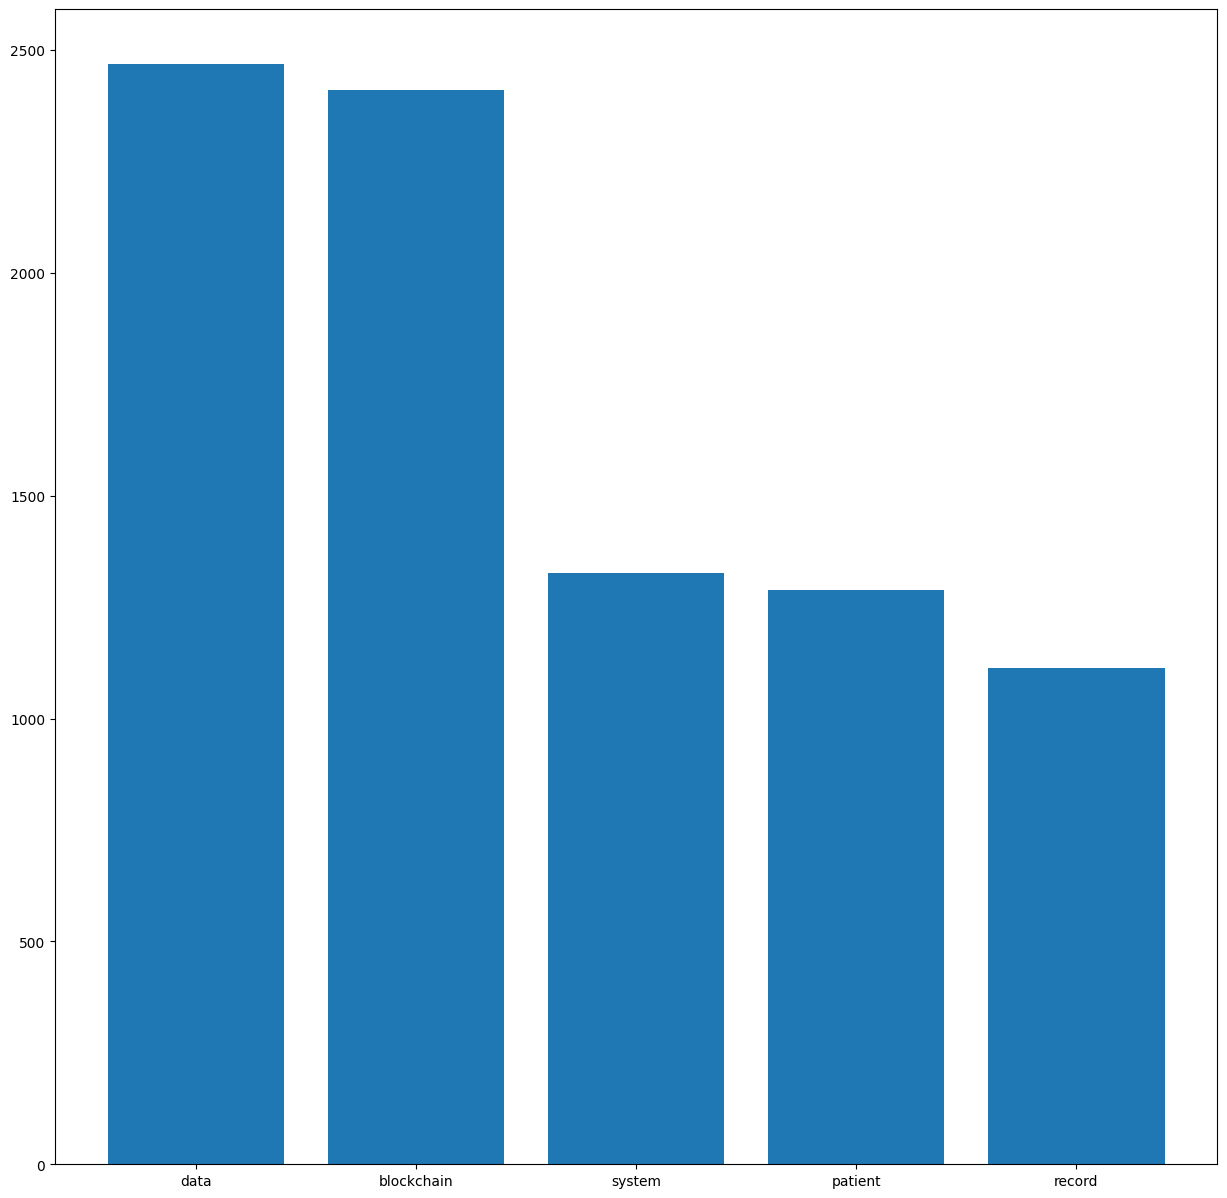

In [24]:
names = list(f.keys())
values = list(f.values())
plt.figure(figsize=(15,15))
plt.bar(range(len(f)), values, tick_label=names)

In [25]:
pip install keybert

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 126.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 83.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu1

In [26]:
from keybert import KeyBERT

In [27]:
from sentence_transformers import SentenceTransformer
import torch

# Ensure model is loaded on GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Load the transformer model directly with GPU support
sentence_model = SentenceTransformer('all-mpnet-base-v2', device=device)
kw_model = KeyBERT(model=sentence_model)

Using device: cuda


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [28]:
df['content_new']=df['content']

In [29]:
for i in range(0,20):
    keywords = kw_model.extract_keywords(df['content'][i],keyphrase_ngram_range=(1, 3),highlight=False, top_n=70)
    keywords_list= list(dict(keywords).keys())
    s=""
    for kw in keywords_list:
        # print(kw)
        s=s+" "+kw
    df['content_new'][i]=s

In [30]:
d=Counter(" ".join(df["content_new"]).split()).most_common(5)
f=dict(d)
f

{'blockchain': 703,
 'healthcare': 316,
 'data': 267,
 'medical': 249,
 'health': 192}

<BarContainer object of 5 artists>

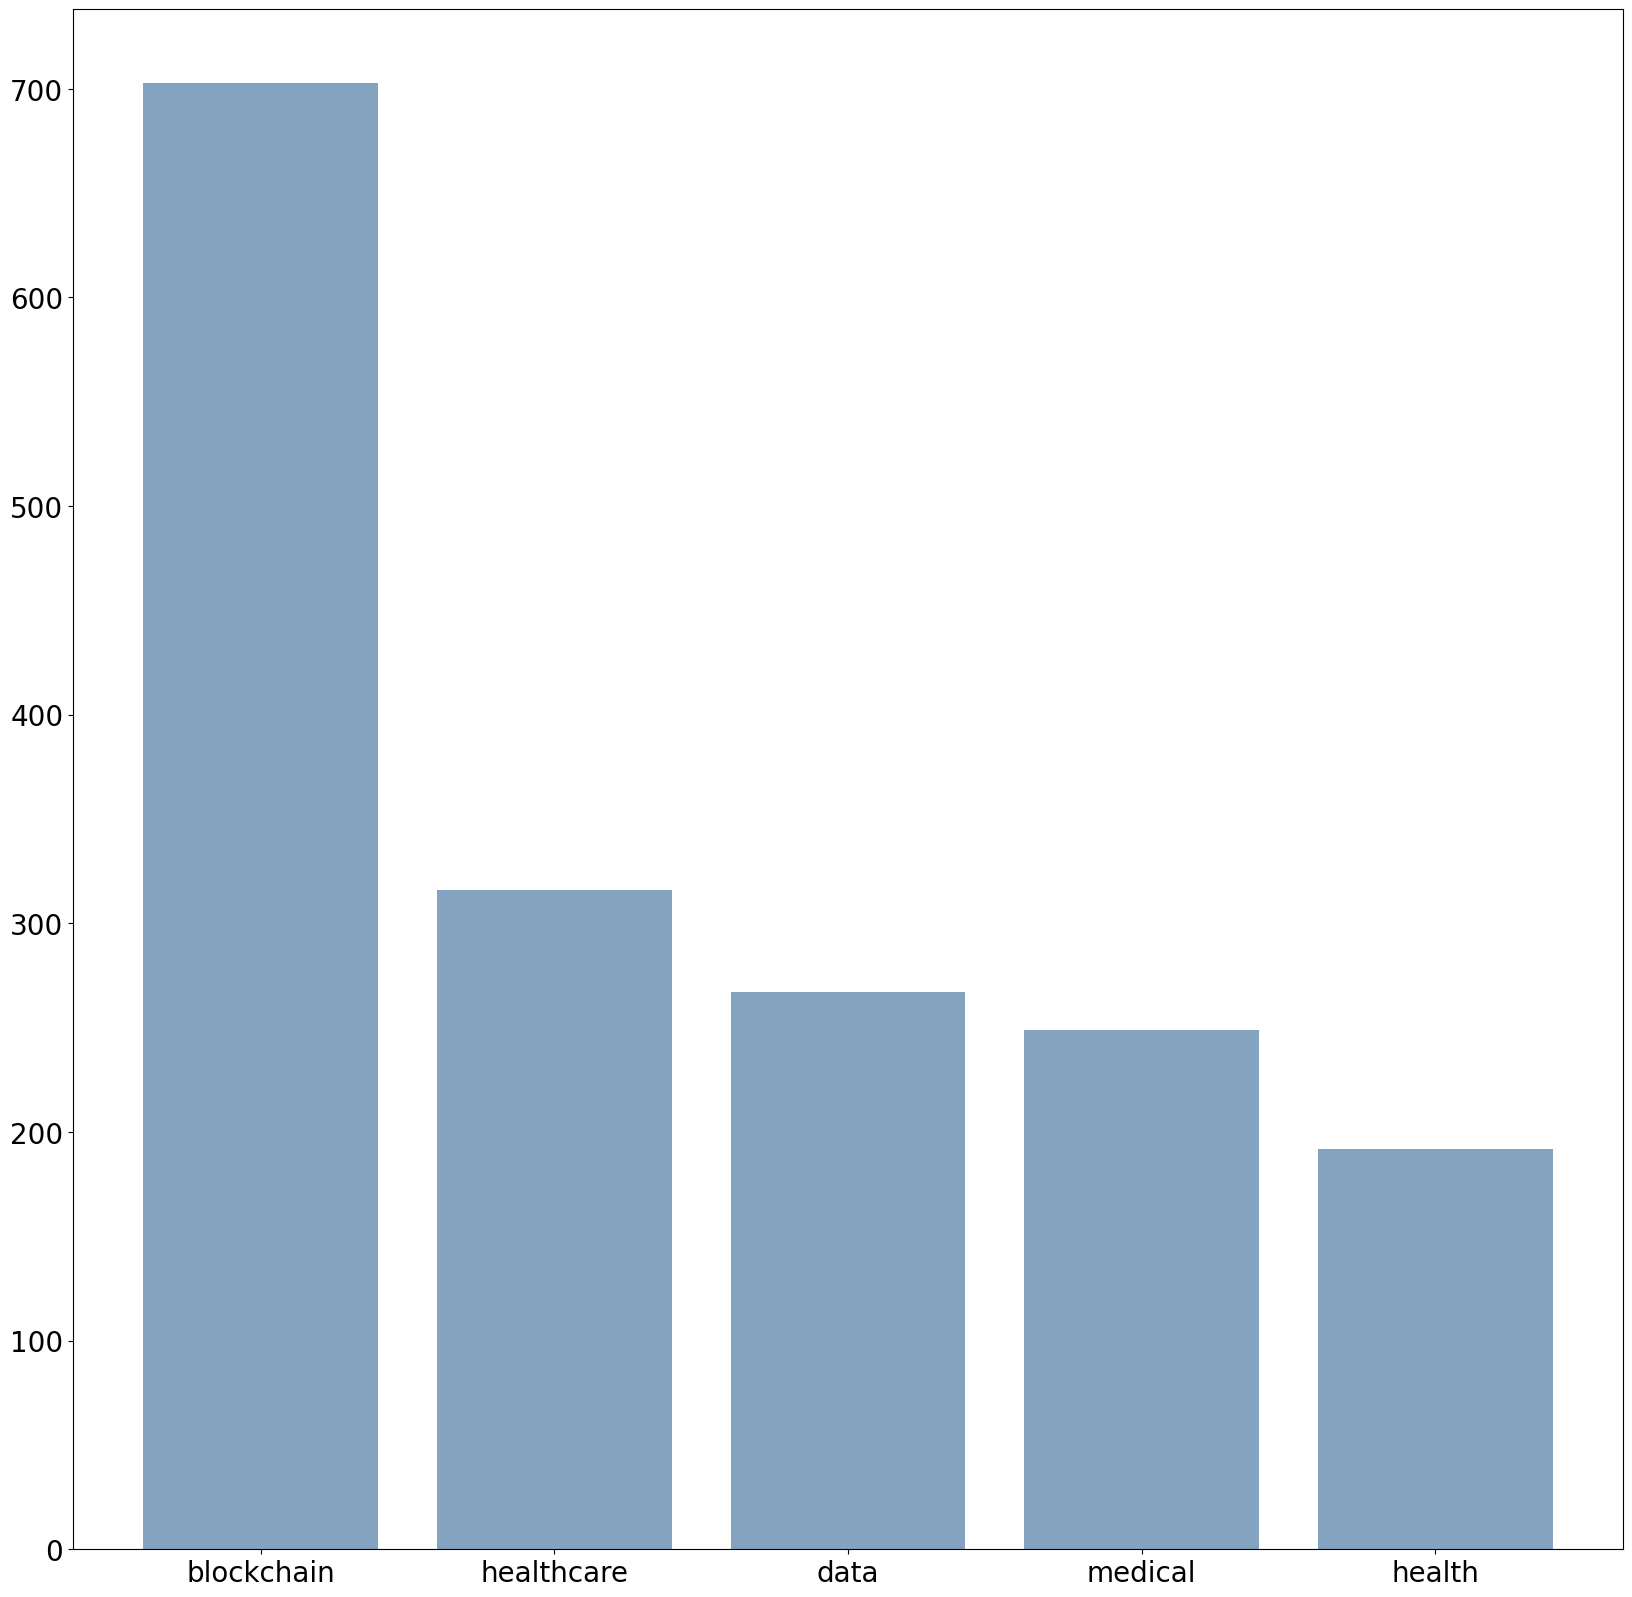

In [31]:
names = list(f.keys())
values = list(f.values())
plt.figure(figsize=(20,20))
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
plt.bar(range(len(f)), values, tick_label=names,color=(0.2, 0.4, 0.6, 0.6))

In [32]:
df.head()

,Unnamed: 0,Name,content,content_new
0,0,paper 1,journal biomedical informatics content list av...,health record blockchain blockchain medical b...
1,1,paper 2,available online www sciencedirect com availab...,technology blockchain medical blockchain mana...
2,2,paper 3,database privacy design healthcare information...,blockchain management healthcare patient bloc...
3,3,paper 4,blockhr blockchain based healthcare record man...,healthcare blockchain using healthcare blockc...
4,4,paper 5,international conference innovative data commu...,patient information blockchain health record ...


In [33]:
df.to_csv('berthealthRecord.csv')

In [34]:
import pandas as pd
df=pd.read_csv('berthealthRecord.csv')

In [35]:
x_train=df['content_new'].to_numpy()

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
tf_idf_vectorizer=TfidfVectorizer(min_df=0.07)

cv_vectorizer= CountVectorizer()

In [37]:
tf_idf_arr= tf_idf_vectorizer.fit_transform(x_train)

# cv_arr=cv_vectorizer.fit_transform(x_train)

In [38]:
import numpy as np

In [39]:
tf_idf_arr

<20x155 sparse matrix of type '<class 'numpy.float64'>'
	with 755 stored elements in Compressed Sparse Row format>

In [40]:
vocab_tf_idf = tf_idf_vectorizer.get_feature_names_out()

In [41]:
from sklearn.decomposition import LatentDirichletAllocation
lda_model= LatentDirichletAllocation(n_components=4, max_iter = 200, random_state=20)

X_topics= lda_model.fit_transform(tf_idf_arr)

topic_words=lda_model.components_

In [42]:
# Log Likelyhood: Higher the better
print("Log Likelihood: ", lda_model.score(tf_idf_arr))

# Perplexity: Lower the better. Perplexity = exp(-1. * log-likelihood per word)
print("Perplexity: ", lda_model.perplexity(tf_idf_arr))

# See model parameters
print(lda_model.get_params())


Log Likelihood:  -442.63209808488466
Perplexity:  392.4988857329207
{'batch_size': 128, 'doc_topic_prior': None, 'evaluate_every': -1, 'learning_decay': 0.7, 'learning_method': 'batch', 'learning_offset': 10.0, 'max_doc_update_iter': 100, 'max_iter': 200, 'mean_change_tol': 0.001, 'n_components': 4, 'n_jobs': None, 'perp_tol': 0.1, 'random_state': 20, 'topic_word_prior': None, 'total_samples': 1000000.0, 'verbose': 0}


In [43]:
topic_number =[]
word=[]

In [44]:
n_top_words=5

# for i, topic_dist in enumerate(topic_words):

#     sorted_topic_dist = np.argsort(topic_dist)
#     topic_words = np.array(vocab_tf_idf)[sorted_topic_dist]

#     topic_words= topic_words[:-n_top_words:-1]
#     print("topic", str(i+1), topic_words)
#     topic_number.append("topic"+str(i+1))
#     word.append(topic_words)
#     print(" ")

In [45]:
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary

# Preprocessing: Tokenize and clean your text data (if not already done)
documents = [doc.split() for doc in df['content']]  # Replace with actual tokenized text data

# Create a Gensim dictionary and corpus
dictionary = Dictionary(documents)
corpus = [dictionary.doc2bow(doc) for doc in documents]

# Store topics' words and calculate coherence
topic_coherence_scores = []

# Iterate over each topic
for i, topic_dist in enumerate(topic_words):

    sorted_topic_dist = np.argsort(topic_dist)
    topic_words = np.array(vocab_tf_idf)[sorted_topic_dist]
    topic_words = topic_words[:-n_top_words:-1]
    print("Topic", str(i+1), topic_words)
    topic_number.append("Topic" + str(i+1))
    word.append(topic_words)

    # Calculate coherence score for each topic using gensim's CoherenceModel
    gensim_lda_topic = [dictionary[word_id] for word_id in sorted_topic_dist[-n_top_words:]]

    coherence_model = CoherenceModel(
        topics=[gensim_lda_topic],
        texts=documents,
        dictionary=dictionary,
        coherence='c_v'  # You can choose 'c_v', 'u_mass', or 'c_npmi'
    )

    coherence_score = coherence_model.get_coherence()
    topic_coherence_scores.append(coherence_score)
    print(f"Coherence score for Topic {i+1}: {coherence_score:.4f}")

    print(" ")

# Display all topics' coherence scores
print("\nTopic Coherence Scores:")
for idx, score in enumerate(topic_coherence_scores):
    print(f"Topic {idx+1}: {score:.4f}")


Topic 1 ['applying' 'make' 'involved' 'section']
Coherence score for Topic 1: 0.3166
 
Topic 2 ['blockchain' 'healthcare' 'medical' 'data']
Coherence score for Topic 2: 0.2412
 
Topic 3 ['applying' 'make' 'involved' 'section']
Coherence score for Topic 3: 0.3166
 
Topic 4 ['applying' 'make' 'involved' 'section']
Coherence score for Topic 4: 0.3166
 

Topic Coherence Scores:
Topic 1: 0.3166
Topic 2: 0.2412
Topic 3: 0.3166
Topic 4: 0.3166


In [46]:
topic_df=pd.DataFrame(topic_number)
topic_df["topic words"]=word

In [47]:
print(topic_df.to_string())

        0                              topic words
0  Topic1      [applying, make, involved, section]
1  Topic2  [blockchain, healthcare, medical, data]
2  Topic3      [applying, make, involved, section]
3  Topic4      [applying, make, involved, section]


In [48]:
doc_name=[]
doc_top=[]

In [49]:
doc_topic=lda_model.transform(tf_idf_arr)

for n in range(doc_topic.shape[0]):

    topic_doc=doc_topic[n].argmax()

    print("document", n+1, " - - Topic: ", topic_doc+1)
    doc_name.append(n+1)
    doc_top.append(topic_doc+1)

document 1  - - Topic:  2
document 2  - - Topic:  2
document 3  - - Topic:  2
document 4  - - Topic:  2
document 5  - - Topic:  2
document 6  - - Topic:  2
document 7  - - Topic:  2
document 8  - - Topic:  2
document 9  - - Topic:  2
document 10  - - Topic:  2
document 11  - - Topic:  2
document 12  - - Topic:  2
document 13  - - Topic:  2
document 14  - - Topic:  2
document 15  - - Topic:  2
document 16  - - Topic:  2
document 17  - - Topic:  2
document 18  - - Topic:  2
document 19  - - Topic:  2
document 20  - - Topic:  2


In [50]:
doc=pd.DataFrame(doc_name)
doc["topic"]=doc_top

In [51]:
doc

,0,topic
0,1,2
1,2,2
2,3,2
3,4,2
4,5,2
5,6,2
6,7,2
7,8,2
8,9,2
9,10,2


<Axes: xlabel='topic', ylabel='count'>

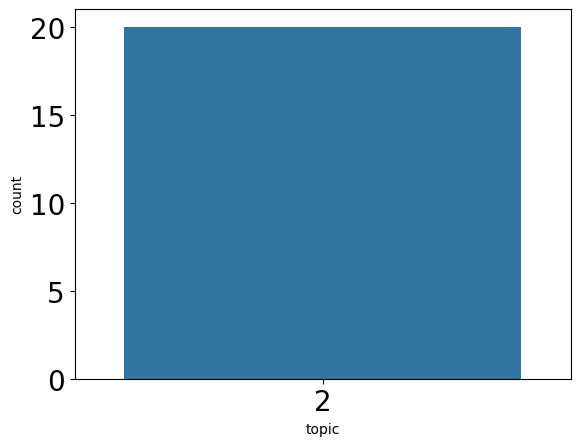

In [52]:
import seaborn as sns
sns.countplot(x ='topic', data = doc)

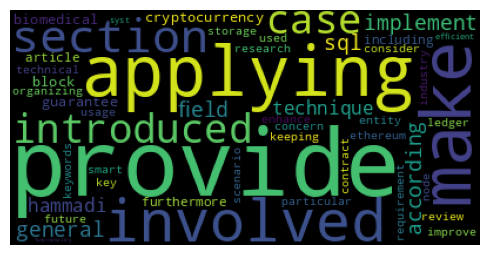

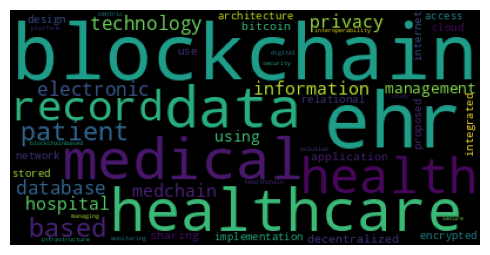

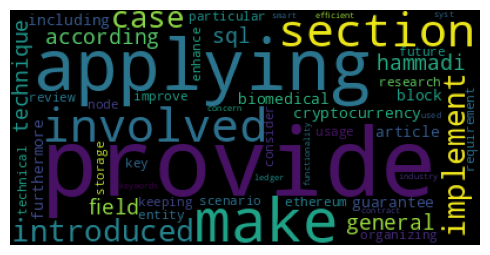

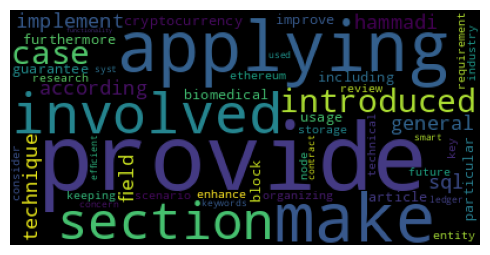

In [53]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
# Generate a word cloud image for given topic
def draw_word_cloud(index):
  imp_words_topic=""
  comp=lda_model.components_[index]
  vocab_comp = zip(vocab_tf_idf, comp)
  sorted_words = sorted(vocab_comp, key= lambda x:x[1], reverse=True)[:50]
  for word in sorted_words:
    imp_words_topic=imp_words_topic+" "+word[0]

  wordcloud = WordCloud().generate(imp_words_topic)
  plt.figure( figsize=(5,5))
  plt.imshow(wordcloud)
  plt.axis("off")
  plt.tight_layout()
  plt.show()
# topic 0
draw_word_cloud(0)
draw_word_cloud(1)
draw_word_cloud(2)
draw_word_cloud(3)